# SentinelGate ML Pipeline



# 1. Load Dataset

In [1]:
#Load Dataset
import pandas as pd

df = pd.read_csv("scanner_training_data.csv")
df.head()

,response_code,response_size,error_message_present,data_exposure_detected,auth_state,attack_type,severity_label
0,500,1103,1,0,2,Path Traversal,High
1,200,65,0,1,1,Information Disclosure,Low
2,403,720,1,0,2,XSS,High
3,500,889,1,0,2,XSS,High
4,401,1038,1,0,2,Path Traversal,High


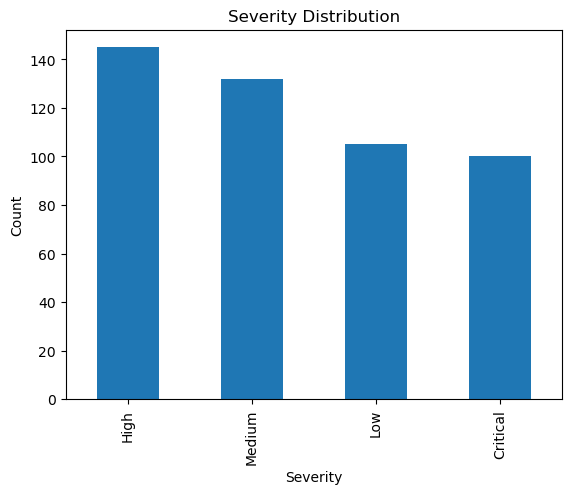

In [2]:
import matplotlib.pyplot as plt

df["severity_label"].value_counts().plot(kind="bar")
plt.title("Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

#### Interpretation of Severity Distribution

This bar chart shows the distribution of vulnerability severity levels within the dataset.

From the visualization, it can be observed that:

- **High severity vulnerabilities** appear most frequently in the dataset.
- **Medium severity cases** also form a significant portion.
- **Low and Critical severities** are slightly less frequent but still well represented.

Overall, the dataset is relatively balanced across severity levels, although there is a slight dominance of High severity cases. This balance is important for training the machine learning model, as it helps prevent bias toward any single class and ensures more reliable predictions across all severity levels.

# 2. Exploratory Analysis

In [3]:
#Feature Analysis
df.groupby("severity_label")[[
    "response_code",
    "response_size",
    "error_message_present",
    "data_exposure_detected",
    "auth_state"
]].mean()

,response_code,response_size,error_message_present,data_exposure_detected,auth_state
severity_label,,,,,
Critical,474.080000,2785.830000,0.930000,0.810000,2.690000
High,433.868966,1463.689655,0.765517,0.289655,2.234483
Low,231.085714,336.676190,0.123810,0.114286,1.000000
Medium,320.227273,800.560606,0.393939,0.272727,1.083333


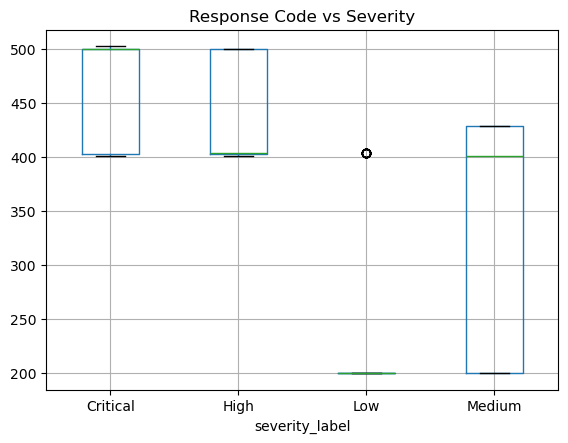

In [4]:
df.boxplot(column="response_code", by="severity_label")
plt.title("Response Code vs Severity")
plt.suptitle("")
plt.show()

#### Interpretation of Response Code vs Severity

This boxplot illustrates the relationship between API response codes and the assigned severity levels of vulnerabilities.

From the visualization, it can be observed that:

- **Critical and High severity vulnerabilities** are mostly associated with higher response codes (around 400–500), indicating server errors or failed requests during attack simulations.
- **Medium severity cases** show a wider spread, suggesting that these vulnerabilities may occur under more varied response conditions.
- **Low severity vulnerabilities** are concentrated around lower response codes, indicating relatively normal or less impactful responses.

Overall, this suggests that abnormal or error-based response codes are strong indicators of higher severity vulnerabilities. This supports the selection of `response_code` as an important feature in the machine learning model.

# 3. Data Preparation

In [5]:
#Encode and Split
from sklearn.model_selection import train_test_split

df_encoded = pd.get_dummies(df, columns=["attack_type"])

X = df_encoded.drop(columns=["severity_label"])
y = df_encoded["severity_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Model Training

In [6]:
#Train Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)

rf_model = RandomForestClassifier(
        n_estimators=400,
        max_depth=7,
        min_samples_split=6,
        min_samples_leaf=3,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=7, min_samples_leaf=3,
                       min_samples_split=6, n_estimators=400, random_state=42)

# 5. Model Evaluation

In [7]:
#Evaluate
from sklearn.metrics import accuracy_score, classification_report

dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred, zero_division=0))

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, zero_division=0))

Decision Tree Accuracy: 0.8556701030927835
              precision    recall  f1-score   support

    Critical       0.74      0.85      0.79        20
        High       0.85      0.79      0.82        29
         Low       0.95      0.86      0.90        21
      Medium       0.89      0.93      0.91        27

    accuracy                           0.86        97
   macro avg       0.86      0.86      0.86        97
weighted avg       0.86      0.86      0.86        97

Random Forest Accuracy: 0.9175257731958762
              precision    recall  f1-score   support

    Critical       0.82      0.90      0.86        20
        High       0.89      0.86      0.88        29
         Low       0.95      1.00      0.98        21
      Medium       1.00      0.93      0.96        27

    accuracy                           0.92        97
   macro avg       0.92      0.92      0.92        97
weighted avg       0.92      0.92      0.92        97



# 6. Feature Importance

In [8]:
# ===============================
# FEATURE IMPORTANCE CHECK
# ===============================

import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)

                                  Feature  Importance
1                           response_size    0.341498
4                              auth_state    0.267284
0                           response_code    0.185824
2                   error_message_present    0.064551
3                  data_exposure_detected    0.063884
11              attack_type_SQL Injection    0.016143
7     attack_type_Excessive Data Exposure    0.012726
10           attack_type_Rate Limit Abuse    0.010953
6       attack_type_Broken Authentication    0.009362
8      attack_type_Information Disclosure    0.007303
5                        attack_type_BOLA    0.006864
13                        attack_type_XSS    0.004954
9              attack_type_Path Traversal    0.004469
12  attack_type_Security Misconfiguration    0.004186


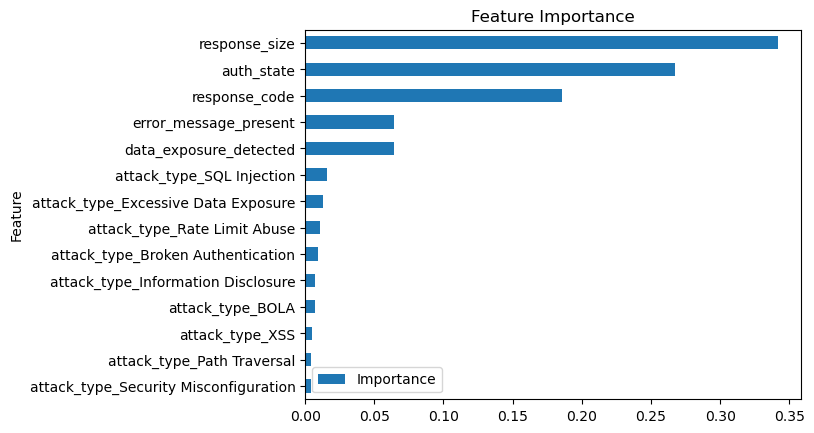

In [9]:
import matplotlib.pyplot as plt

importance_df.plot(kind="barh", x="Feature", y="Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

#### Interpretation of Feature Importance

This chart represents the importance of each feature in the Random Forest model when predicting vulnerability severity.

Key observations include:

- **response_size** is the most influential feature, indicating that the size of API responses plays a major role in determining severity.
- **auth_state** is the second most important feature, showing that authentication conditions (normal, weak, or bypassed) strongly impact vulnerability severity.
- **response_code** also contributes significantly, suggesting that abnormal HTTP responses are good indicators of security issues.
- Features such as **error_message_present** and **data_exposure_detected** have moderate importance.
- Individual attack types contribute less compared to core response-based features.

This confirms that the engineered feature **auth_state** is contributing effectively to the model, as suggested by the supervisor. Overall, the model relies more on response behavior rather than attack type alone, which aligns well with real-world API vulnerability detection.

# 7. Validation Checks

In [10]:
# ===============================
# OVERFITTING CHECK
# ===============================
from sklearn.metrics import accuracy_score

train_pred = rf_model.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy :", accuracy_score(y_test, rf_pred))

Training Accuracy: 0.9428571428571428
Testing Accuracy : 0.9175257731958762


In [11]:
# ===============================
# DATA LEAKAGE CHECK
# ===============================
train_set = set(map(tuple, X_train.values))
test_set = set(map(tuple, X_test.values))

overlap = train_set.intersection(test_set)

print("Number of overlapping rows:", len(overlap))

Number of overlapping rows: 0


In [12]:
# ===============================
# DUPLICATE CHECK
# ===============================
duplicates = df.duplicated(
    subset=[
        "response_code",
        "response_size",
        "error_message_present",
        "data_exposure_detected",
        "auth_state"
    ],
    keep=False
)

print("Duplicate rows:", duplicates.sum())

Duplicate rows: 0


In [13]:
# ===============================
# LABEL CONSISTENCY CHECK
# ===============================
grouped = df.groupby([
    "response_code",
    "response_size",
    "error_message_present",
    "data_exposure_detected",
    "auth_state"
])["severity_label"].nunique()

print("Conflicting rows:", len(grouped[grouped > 1]))

Conflicting rows: 0


In [14]:
# ===============================
# CROSS VALIDATION
# ===============================
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score  

cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

scores = cross_val_score(rf_model, X, y, cv=cv)

print("Cross-validation scores:", scores)
print("Average CV accuracy:", scores.mean())

Cross-validation scores: [0.91304348 0.85507246 0.86956522 0.88405797 0.88405797 0.97101449
 0.91176471]
Average CV accuracy: 0.8983680428693217


# 8. Sample Prediction

In [16]:
#Sample Prediction
sample = {feature: 0 for feature in X.columns}

sample["response_code"] = 500
sample["response_size"] = 2000
sample["error_message_present"] = 1
sample["data_exposure_detected"] = 1
sample["auth_state"] = 3
sample["attack_type_SQL Injection"] = 1

import pandas as pd
sample_df = pd.DataFrame([sample])

print("Predicted Severity:", rf_model.predict(sample_df)[0])

Predicted Severity: Critical
